In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import SimpleITK as sitk
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import timm
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from NoduleDS import NoduleDataset

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [22]:
BATCH_SIZE = 16
NUM_EPOCHS = 25
LEARNING_RATE = 1e-4
IMAGE_SIZE = 224
NUM_WORKERS = 4
WEIGHT_DECAY = 0.01

# Paths
base_path = "./dataset_nodule21/cxr_images/proccessed_data"
images_path = os.path.join(base_path, "new_images")
csv_path = os.path.join(base_path, "metadata_upsampled.csv")

In [23]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=3),
    transforms.ColorJitter(brightness=0.05, contrast=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [24]:
print("Loading metadata...")
df = pd.read_csv(csv_path)
print(f"Total samples: {len(df)}")
print(f"Class distribution:\n{df['label'].value_counts()}")

# Split data: 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print(f"\nTrain: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

# Create datasets
train_dataset = NoduleDataset(train_df, images_path, transform=train_transform)
val_dataset = NoduleDataset(val_df, images_path, transform=val_transform)
test_dataset = NoduleDataset(test_df, images_path, transform=val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                         num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                       num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=NUM_WORKERS, pin_memory=True)

Loading metadata...
Total samples: 8176
Class distribution:
label
1    4428
0    3748
Name: count, dtype: int64

Train: 5723, Val: 1226, Test: 1227


In [26]:
import pandas as pd

# Load your data
df = pd.read_csv(csv_path)

# Check for duplicates in the full dataset
print("=== DUPLICATE CHECK ===")
print(f"Total rows: {len(df)}")
print(f"Unique image names: {df['img_name'].nunique()}")  # or whatever your image column is called
print(f"Duplicate images: {len(df) - df['img_name'].nunique()}")

# After your train/val/test split, check overlap
train_df, temp_df = train_test_split(df, test_size=0.3, stratify=df['label'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=42)

print("\n=== OVERLAP CHECK ===")
train_images = set(train_df['img_name'].values)  # adjust column name
val_images = set(val_df['img_name'].values)
test_images = set(test_df['img_name'].values)

train_val_overlap = train_images & val_images
train_test_overlap = train_images & test_images
val_test_overlap = val_images & test_images

print(f"Train-Val overlap: {len(train_val_overlap)} images")
print(f"Train-Test overlap: {len(train_test_overlap)} images")
print(f"Val-Test overlap: {len(val_test_overlap)} images")

if len(train_val_overlap) > 0:
    print(f"\nWARNING: Found overlapping images between train and val!")
    print(f"Examples: {list(train_val_overlap)[:5]}")

if len(train_test_overlap) > 0:
    print(f"\nWARNING: Found overlapping images between train and test!")
    print(f"Examples: {list(train_test_overlap)[:5]}")

=== DUPLICATE CHECK ===
Total rows: 8176
Unique image names: 7150
Duplicate images: 1026

=== OVERLAP CHECK ===
Train-Val overlap: 192 images
Train-Test overlap: 187 images
Val-Test overlap: 43 images

Examples: ['n0285_aug0.mha', 'n0991.mha', 'n0879_aug0.mha', 'n1059_aug1.mha', 'n1058_aug0.mha']

Examples: ['n0080_aug0.mha', 'n1027_aug0.mha', 'n0770_aug1.mha', 'n1059_aug1.mha', 'n0009_aug0.mha']


DATASET STATISTICS

Train Set:
  Total rows: 5725
  Unique images: 5005
  Augmented images: 2068
  Class 0 (no nodule): 2623
  Class 1 (nodule): 3102

Val Set:
  Total rows: 782
  Unique images: 732
  Augmented images: 0
  Class 0 (no nodule): 557
  Class 1 (nodule): 225

Test Set:
  Total rows: 785
  Unique images: 733
  Augmented images: 0
  Class 0 (no nodule): 568
  Class 1 (nodule): 217


C:\Users\Edrill-LT\AppData\Local\Temp\ipykernel_9428\1519855495.py:213: UserWarning: The figure layout has changed to tight
  plt.tight_layout()



✓ Visualization saved as 'dataset_visualization.png'


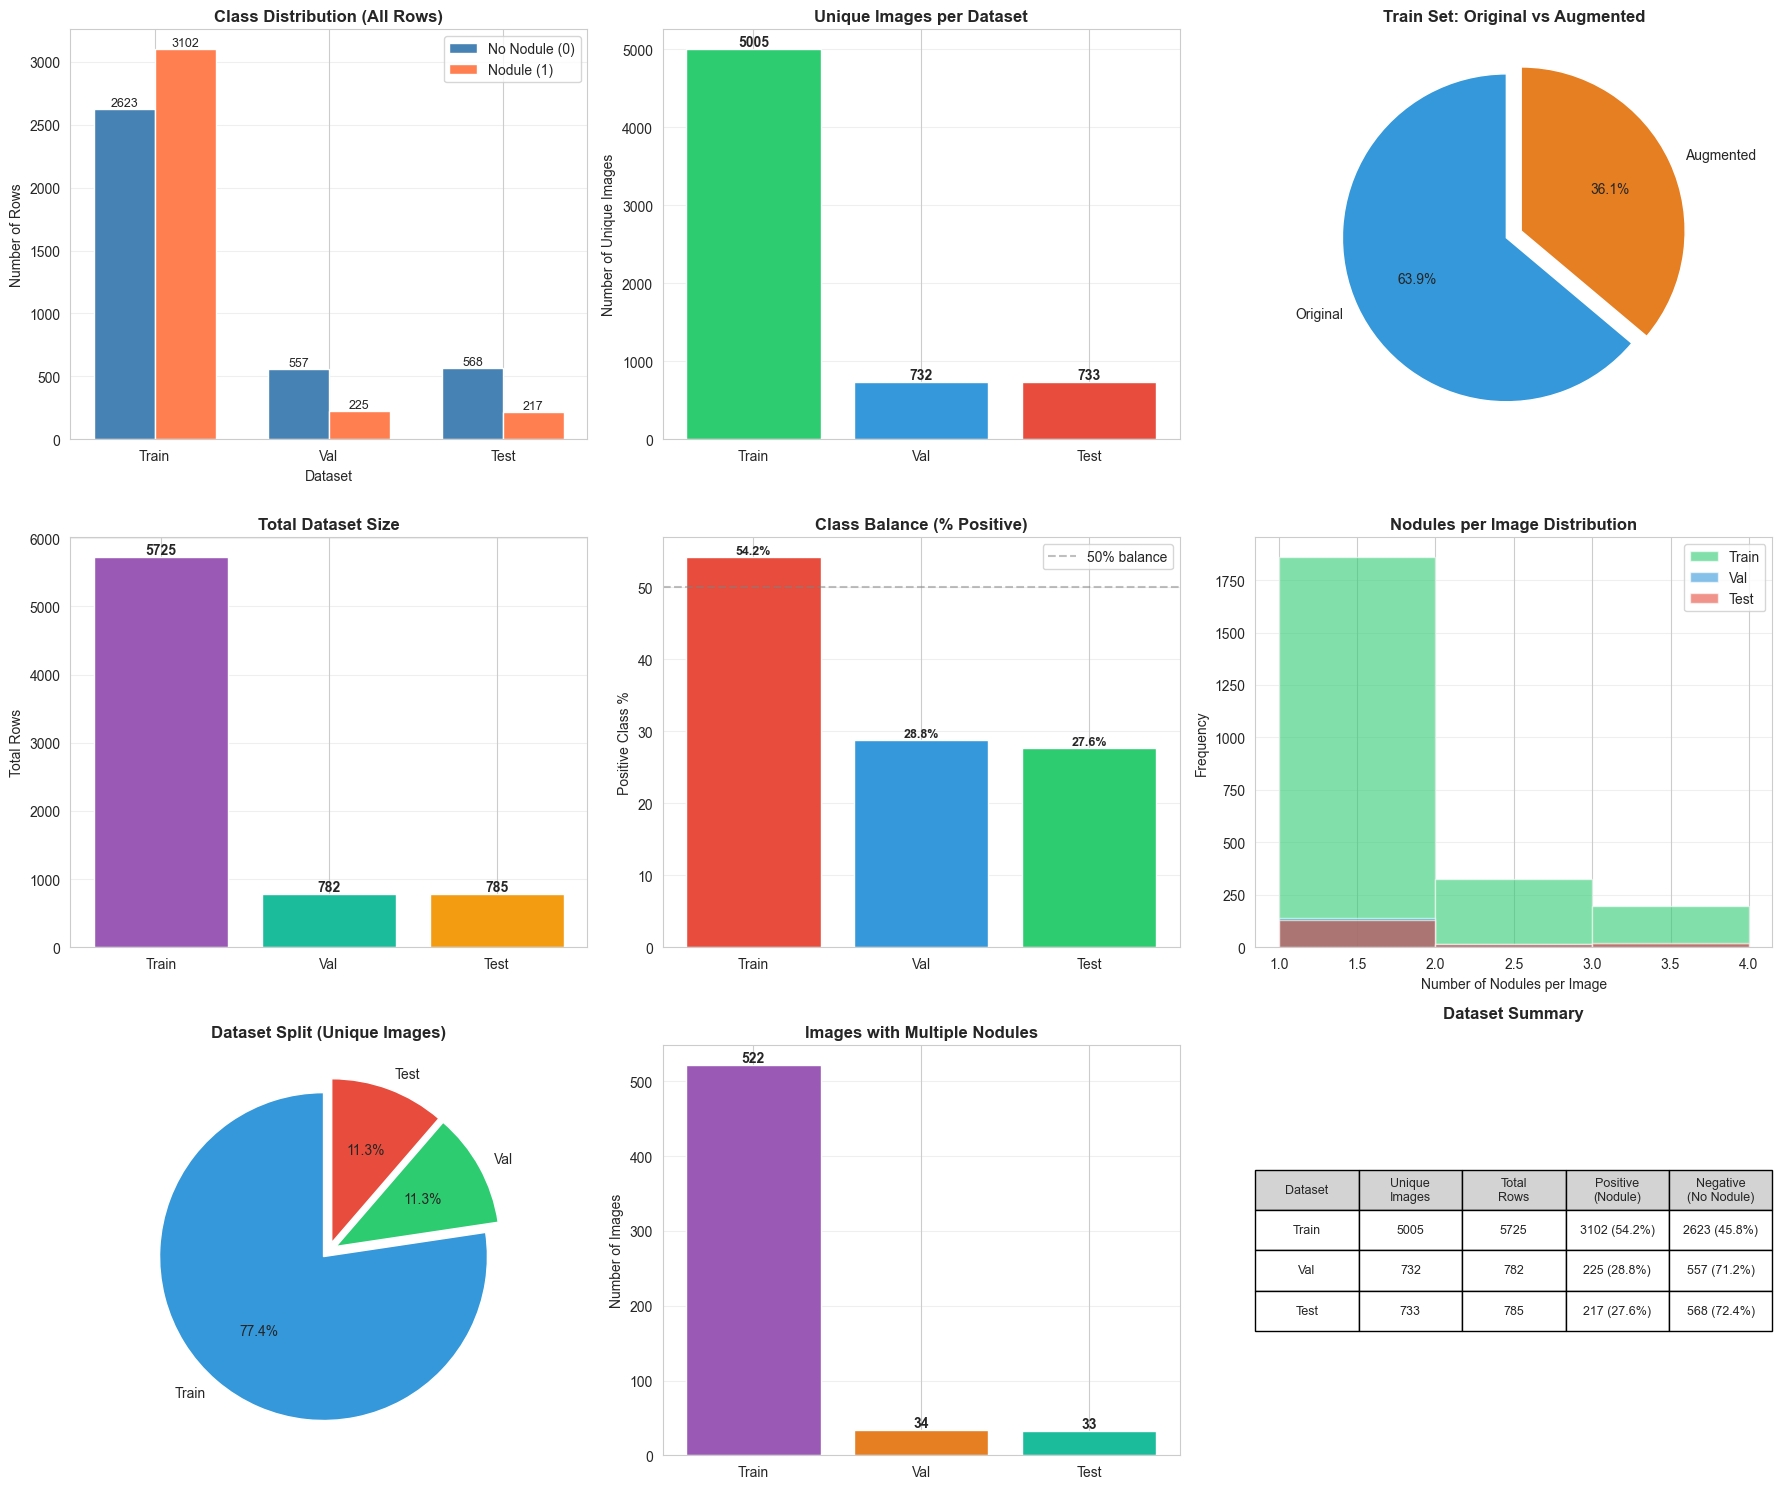

C:\Users\Edrill-LT\AppData\Local\Temp\ipykernel_9428\1519855495.py:272: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Edrill-LT\AppData\Local\Temp\ipykernel_9428\1519855495.py:273: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.savefig('dataset_leakage_check.png', dpi=300, bbox_inches='tight')


✓ Leakage check visualization saved as 'dataset_leakage_check.png'


c:\Users\Edrill-LT\Documents\Projects\Python\Thoracic-Disease-Classifier-ResNet50\.torch\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


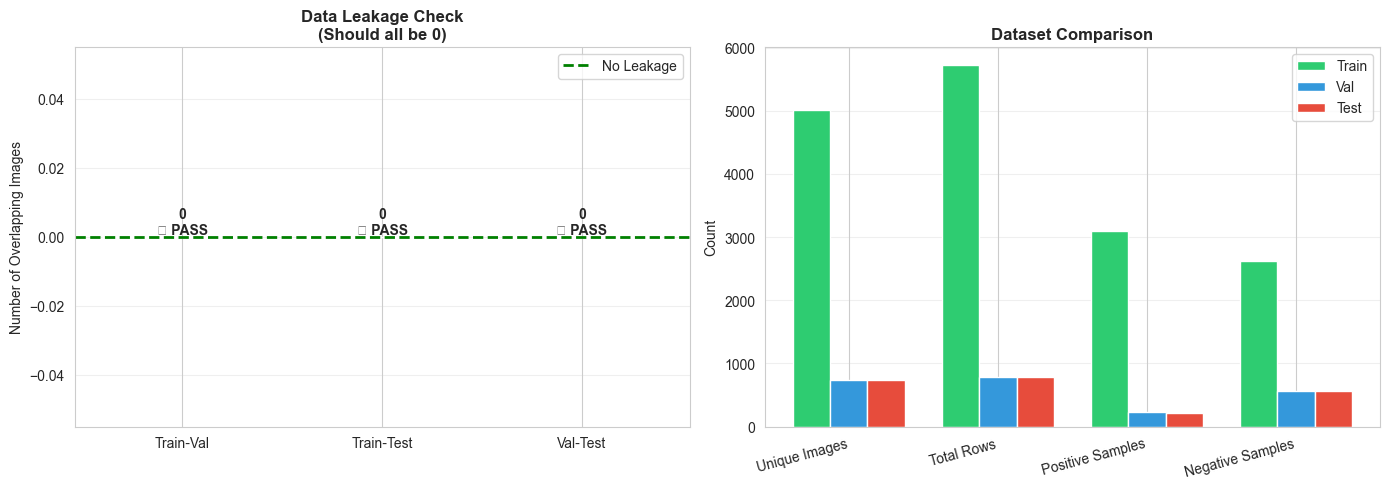


VISUALIZATION COMPLETE!


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Paths
base_path = "./dataset_nodule21/cxr_images/proccessed_data/split_data"
train_csv = os.path.join(base_path, "train", "metadata_train.csv")
val_csv = os.path.join(base_path, "val", "metadata_val.csv")
test_csv = os.path.join(base_path, "test", "metadata_test.csv")

# Load data
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

# Add dataset column
train_df['dataset'] = 'Train'
val_df['dataset'] = 'Val'
test_df['dataset'] = 'Test'

print("="*60)
print("DATASET STATISTICS")
print("="*60)

# Print statistics
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    print(f"\n{name} Set:")
    print(f"  Total rows: {len(df)}")
    print(f"  Unique images: {df['img_name'].nunique()}")
    print(f"  Augmented images: {df['img_name'].str.contains('_aug').sum()}")
    print(f"  Class 0 (no nodule): {len(df[df['label']==0])}")
    print(f"  Class 1 (nodule): {len(df[df['label']==1])}")

# Create figure with subplots
fig = plt.figure(constrained_layout=True, figsize=(18, 15))

# 1. Class Distribution by Dataset (Rows)
ax1 = plt.subplot(3, 3, 1)
datasets = ['Train', 'Val', 'Test']
class_0 = [len(train_df[train_df['label']==0]), 
           len(val_df[val_df['label']==0]), 
           len(test_df[test_df['label']==0])]
class_1 = [len(train_df[train_df['label']==1]), 
           len(val_df[val_df['label']==1]), 
           len(test_df[test_df['label']==1])]

x = np.arange(len(datasets))
width = 0.35
bars1 = ax1.bar(x - width/2, class_0, width, label='No Nodule (0)', color='steelblue')
bars2 = ax1.bar(x + width/2, class_1, width, label='Nodule (1)', color='coral')

ax1.set_xlabel('Dataset')
ax1.set_ylabel('Number of Rows')
ax1.set_title('Class Distribution (All Rows)', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(datasets)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=9)

# 2. Unique Images by Dataset
ax2 = plt.subplot(3, 3, 2)
unique_images = [train_df['img_name'].nunique(), 
                 val_df['img_name'].nunique(), 
                 test_df['img_name'].nunique()]
bars = ax2.bar(datasets, unique_images, color=['#2ecc71', '#3498db', '#e74c3c'])
ax2.set_ylabel('Number of Unique Images')
ax2.set_title('Unique Images per Dataset', fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. Augmented vs Original (Train only)
ax3 = plt.subplot(3, 3, 3)
train_original = (~train_df['img_name'].str.contains('_aug')).sum()
train_augmented = train_df['img_name'].str.contains('_aug').sum()
sizes = [train_original, train_augmented]
colors = ['#3498db', '#e67e22']
explode = (0.05, 0.05)
ax3.pie(sizes, explode=explode, labels=['Original', 'Augmented'], 
        autopct='%1.1f%%', startangle=90, colors=colors)
ax3.set_title('Train Set: Original vs Augmented', fontweight='bold')

# 4. Total Dataset Size
ax4 = plt.subplot(3, 3, 4)
total_rows = [len(train_df), len(val_df), len(test_df)]
bars = ax4.bar(datasets, total_rows, color=['#9b59b6', '#1abc9c', '#f39c12'])
ax4.set_ylabel('Total Rows')
ax4.set_title('Total Dataset Size', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 5. Class Balance Ratio
ax5 = plt.subplot(3, 3, 5)
train_ratio = len(train_df[train_df['label']==1]) / len(train_df) * 100
val_ratio = len(val_df[val_df['label']==1]) / len(val_df) * 100
test_ratio = len(test_df[test_df['label']==1]) / len(test_df) * 100
ratios = [train_ratio, val_ratio, test_ratio]

bars = ax5.bar(datasets, ratios, color=['#e74c3c', '#3498db', '#2ecc71'])
ax5.set_ylabel('Positive Class %')
ax5.set_title('Class Balance (% Positive)', fontweight='bold')
ax5.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='50% balance')
ax5.legend()
ax5.grid(axis='y', alpha=0.3)

for bar, ratio in zip(bars, ratios):
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{ratio:.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# 6. Nodules per Image Distribution (Images with nodules only)
ax6 = plt.subplot(3, 3, 6)
combined_df = pd.concat([train_df, val_df, test_df])
nodule_images = combined_df[combined_df['label'] == 1]
nodules_per_img = nodule_images.groupby(['dataset', 'img_name']).size().reset_index(name='count')

for dataset, color in [('Train', '#2ecc71'), ('Val', '#3498db'), ('Test', '#e74c3c')]:
    data = nodules_per_img[nodules_per_img['dataset'] == dataset]['count']
    ax6.hist(data, bins=range(1, data.max()+2), alpha=0.6, label=dataset, color=color)

ax6.set_xlabel('Number of Nodules per Image')
ax6.set_ylabel('Frequency')
ax6.set_title('Nodules per Image Distribution', fontweight='bold')
ax6.legend()
ax6.grid(axis='y', alpha=0.3)

# 7. Dataset Split Proportion (by unique images)
ax7 = plt.subplot(3, 3, 7)
unique_counts = [train_df['img_name'].nunique(), 
                 val_df['img_name'].nunique(), 
                 test_df['img_name'].nunique()]
colors_pie = ['#3498db', '#2ecc71', '#e74c3c']
explode = (0.05, 0.05, 0.05)
ax7.pie(unique_counts, explode=explode, labels=['Train', 'Val', 'Test'], 
        autopct='%1.1f%%', startangle=90, colors=colors_pie)
ax7.set_title('Dataset Split (Unique Images)', fontweight='bold')

# 8. Images with Multiple Nodules
ax8 = plt.subplot(3, 3, 8)
multi_nodule_counts = []
for df, name in [(train_df, 'Train'), (val_df, 'Val'), (test_df, 'Test')]:
    nodule_imgs = df[df['label'] == 1]
    multi = nodule_imgs.groupby('img_name').size()
    multi_nodule_counts.append((multi > 1).sum())

bars = ax8.bar(datasets, multi_nodule_counts, color=['#9b59b6', '#e67e22', '#1abc9c'])
ax8.set_ylabel('Number of Images')
ax8.set_title('Images with Multiple Nodules', fontweight='bold')
ax8.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    ax8.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# 9. Summary Table
ax9 = plt.subplot(3, 3, 9)
ax9.axis('tight')
ax9.axis('off')

summary_data = []
for name, df in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    unique_imgs = df['img_name'].nunique()
    total_rows = len(df)
    pos_rows = len(df[df['label']==1])
    neg_rows = len(df[df['label']==0])
    pos_pct = (pos_rows / total_rows * 100) if total_rows > 0 else 0
    
    summary_data.append([
        name,
        unique_imgs,
        total_rows,
        f"{pos_rows} ({pos_pct:.1f}%)",
        f"{neg_rows} ({100-pos_pct:.1f}%)"
    ])

table = ax9.table(cellText=summary_data,
                  colLabels=['Dataset', 'Unique\nImages', 'Total\nRows', 
                            'Positive\n(Nodule)', 'Negative\n(No Nodule)'],
                  cellLoc='center',
                  loc='center',
                  colColours=['lightgray']*5)
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)
ax9.set_title('Dataset Summary', fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('dataset_visualization.png', dpi=300, bbox_inches='tight')
print(f"\n✓ Visualization saved as 'dataset_visualization.png'")
plt.show()

# Additional: Overlap Verification Visual
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

# Venn-like visualization for overlap check
ax_overlap = axes[0]
train_base = set(train_df['img_name'].str.replace(r'_aug\d+', '', regex=True))
val_base = set(val_df['img_name'])
test_base = set(test_df['img_name'])

overlap_data = {
    'Train-Val': len(train_base & val_base),
    'Train-Test': len(train_base & test_base),
    'Val-Test': len(val_base & test_base)
}

colors_overlap = ['green' if v == 0 else 'red' for v in overlap_data.values()]
bars = ax_overlap.bar(overlap_data.keys(), overlap_data.values(), color=colors_overlap)
ax_overlap.set_ylabel('Number of Overlapping Images')
ax_overlap.set_title('Data Leakage Check\n(Should all be 0)', fontweight='bold')
ax_overlap.axhline(y=0, color='green', linestyle='--', linewidth=2, label='No Leakage')
ax_overlap.grid(axis='y', alpha=0.3)
ax_overlap.legend()

for bar, (key, val) in zip(bars, overlap_data.items()):
    height = bar.get_height()
    status = '✓ PASS' if val == 0 else '✗ FAIL'
    ax_overlap.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(val)}\n{status}',
                   ha='center', va='bottom', fontsize=10, fontweight='bold')

# Dataset split visualization
ax_split = axes[1]
categories = ['Unique Images', 'Total Rows', 'Positive Samples', 'Negative Samples']
train_stats = [train_df['img_name'].nunique(), len(train_df), 
               len(train_df[train_df['label']==1]), len(train_df[train_df['label']==0])]
val_stats = [val_df['img_name'].nunique(), len(val_df), 
             len(val_df[val_df['label']==1]), len(val_df[val_df['label']==0])]
test_stats = [test_df['img_name'].nunique(), len(test_df), 
              len(test_df[test_df['label']==1]), len(test_df[test_df['label']==0])]

x = np.arange(len(categories))
width = 0.25

bars1 = ax_split.bar(x - width, train_stats, width, label='Train', color='#2ecc71')
bars2 = ax_split.bar(x, val_stats, width, label='Val', color='#3498db')
bars3 = ax_split.bar(x + width, test_stats, width, label='Test', color='#e74c3c')

ax_split.set_ylabel('Count')
ax_split.set_title('Dataset Comparison', fontweight='bold')
ax_split.set_xticks(x)
ax_split.set_xticklabels(categories, rotation=15, ha='right')
ax_split.legend()
ax_split.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('dataset_leakage_check.png', dpi=300, bbox_inches='tight')
print(f"✓ Leakage check visualization saved as 'dataset_leakage_check.png'")
plt.show()

print("\n" + "="*60)
print("VISUALIZATION COMPLETE!")
print("="*60)

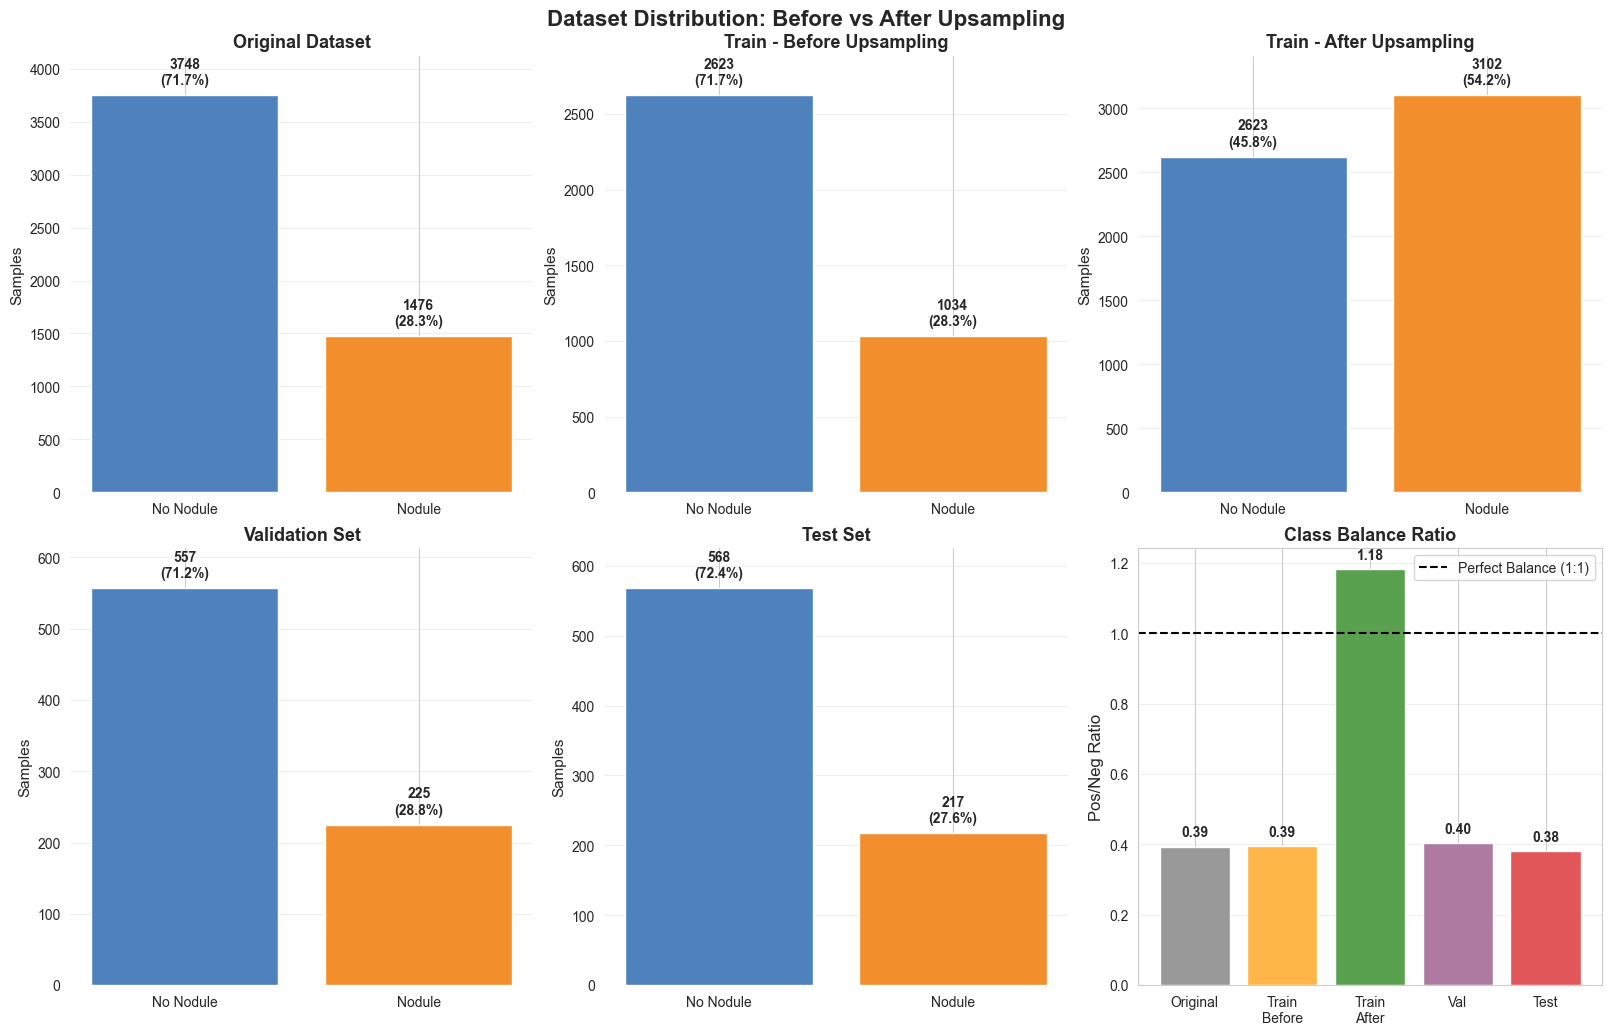

✓ Saved: before_after_upsampling_clean.png


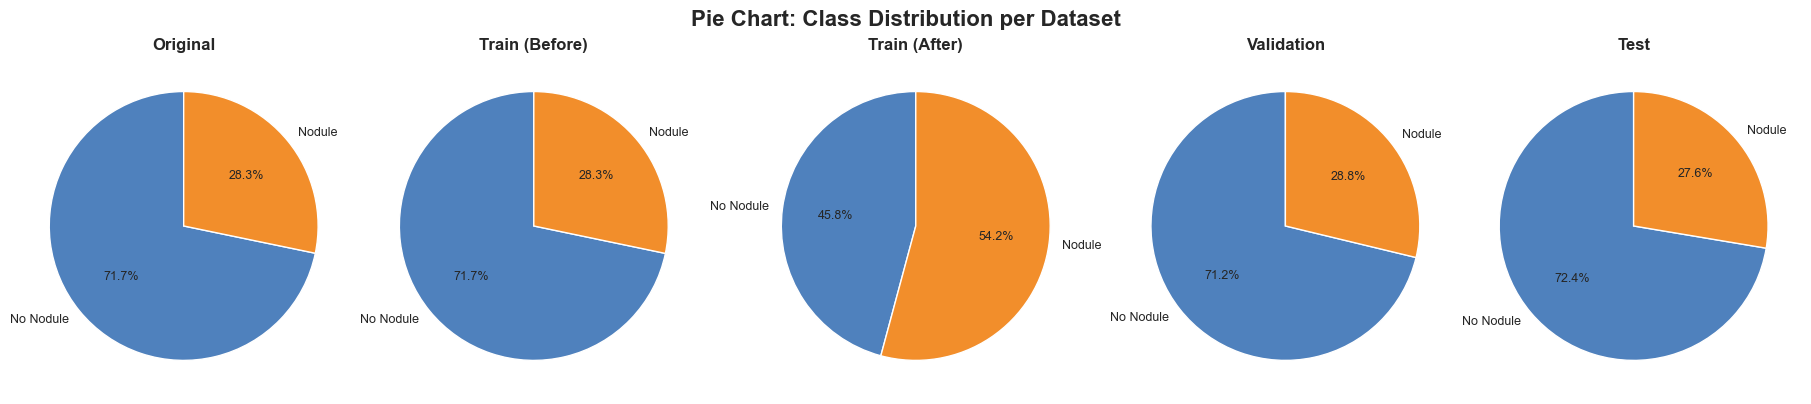

✓ Saved: pie_distribution.png

Visualization complete!


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Paths
base_path = "./dataset_nodule21/cxr_images/proccessed_data"
original_csv = base_path + "/metadata.csv"
train_csv = base_path + "/split_data/train/metadata_train.csv"
val_csv = base_path + "/split_data/val/metadata_val.csv"
test_csv = base_path + "/split_data/test/metadata_test.csv"

# Load data
original_df = pd.read_csv(original_csv)
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
test_df = pd.read_csv(test_csv)

# Function to safely get counts
def get_counts(df):
    vc = df['label'].value_counts().sort_index()
    return vc.get(0, 0), vc.get(1, 0)

# Gather stats
original_0, original_1 = get_counts(original_df)
train_before_0, train_before_1 = get_counts(train_df[~train_df['img_name'].str.contains('_aug')])
train_after_0, train_after_1 = get_counts(train_df)
val_0, val_1 = get_counts(val_df)
test_0, test_1 = get_counts(test_df)

# Ratios
ratios = [
    original_1 / original_0 if original_0 else 0,
    train_before_1 / train_before_0 if train_before_0 else 0,
    train_after_1 / train_after_0 if train_after_0 else 0,
    val_1 / val_0 if val_0 else 0,
    test_1 / test_0 if test_0 else 0
]

# ======= Visualization ======= #
fig, axes = plt.subplots(2, 3, figsize=(16, 10), constrained_layout=True)

datasets = [
    ("Original Dataset", [original_0, original_1]),
    ("Train - Before Upsampling", [train_before_0, train_before_1]),
    ("Train - After Upsampling", [train_after_0, train_after_1]),
    ("Validation Set", [val_0, val_1]),
    ("Test Set", [test_0, test_1])
]
labels = ['No Nodule', 'Nodule']
colors = ['#4F81BD', '#F28E2B']

# --- BAR PLOTS --- #
for ax, (title, counts) in zip(axes.flat[:5], datasets):
    bars = ax.bar(labels, counts, color=colors)
    ax.margins(y=0.1)
    ax.set_title(title, fontweight='bold', fontsize=13)
    ax.set_ylabel('Samples', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2., count + max(counts)*0.02,
                f'{int(count)}\n({count/sum(counts)*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    # Remove outlines (no edgecolor)
    for spine in ax.spines.values():
        spine.set_visible(False)

# --- CLASS BALANCE RATIO --- #
ax6 = axes[1, 2]
stages = ['Original', 'Train\nBefore', 'Train\nAfter', 'Val', 'Test']
bars = ax6.bar(stages, ratios, color=['#999999', '#FFB547', '#59A14F', '#AF7AA1', '#E15759'])
ax6.axhline(y=1.0, color='black', linestyle='--', linewidth=1.5, label='Perfect Balance (1:1)')
ax6.set_ylabel('Pos/Neg Ratio', fontsize=12)
ax6.set_title('Class Balance Ratio', fontweight='bold', fontsize=13)
ax6.legend()
ax6.grid(axis='y', alpha=0.3)
for bar, ratio in zip(bars, ratios):
    ax6.text(bar.get_x() + bar.get_width()/2., ratio + 0.02,
             f'{ratio:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.suptitle('Dataset Distribution: Before vs After Upsampling', 
             fontsize=16, fontweight='bold', y=1.02)
plt.savefig('before_after_upsampling_clean.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: before_after_upsampling_clean.png")

# ======= PIE CHARTS ======= #
pie_data = [
    ("Original", [original_0, original_1]),
    ("Train (Before)", [train_before_0, train_before_1]),
    ("Train (After)", [train_after_0, train_after_1]),
    ("Validation", [val_0, val_1]),
    ("Test", [test_0, test_1])
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4), constrained_layout=True)
for ax, (title, counts) in zip(axes, pie_data):
    ax.pie(counts, labels=['No Nodule', 'Nodule'], colors=colors, autopct='%1.1f%%',
           startangle=90, textprops={'fontsize': 9})
    ax.set_title(title, fontweight='bold', fontsize=12)
plt.suptitle("Pie Chart: Class Distribution per Dataset", fontsize=16, fontweight='bold')
plt.savefig('pie_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: pie_distribution.png")
print("\nVisualization complete!")


In [5]:
print("\nInitializing ViT-Small model...")
model = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=2)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Learning rate scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)


Initializing ViT-Small model...


In [6]:
# %% Training Functions
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    pbar = tqdm(loader, desc='Training')
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().detach().numpy())
        
        pbar.set_postfix({'loss': running_loss/len(loader), 'acc': 100.*correct/total})
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs

In [7]:
# %% Training Loop
print("\nStarting training...")
history = {
    'train_loss': [], 'train_acc': [], 'train_auc': [], 'train_precision': [],
    'val_loss': [], 'val_acc': [], 'val_auc': [], 'val_precision': []
}

best_val_acc = 0.0
best_model_path = 'best_vit_nodule_model.pth'

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc, train_preds, train_labels, train_probs = train_epoch(
        model, train_loader, criterion, optimizer, device)
    
    # Calculate train metrics
    from sklearn.metrics import precision_score
    train_auc = roc_auc_score(train_labels, train_probs)
    train_precision = precision_score(train_labels, train_preds, average='binary', zero_division=0)
    
    # Validate
    val_loss, val_acc, val_preds, val_labels, val_probs = validate(
        model, val_loader, criterion, device)
    
    # Calculate val metrics
    val_auc = roc_auc_score(val_labels, val_probs)
    val_precision = precision_score(val_labels, val_preds, average='binary', zero_division=0)
    
    # Step scheduler
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_auc'].append(train_auc)
    history['train_precision'].append(train_precision)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)
    history['val_precision'].append(val_precision)
    
    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%, Train AUC: {train_auc:.4f}, Train Precision: {train_precision:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%, Val AUC: {val_auc:.4f}, Val Precision: {val_precision:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_auc': val_auc,
        }, best_model_path)
        print(f"✓ Saved best model (Val Acc: {val_acc:.2f}%, Val AUC: {val_auc:.4f})")

print("\nTraining completed!")


Starting training...

Epoch 1/25
--------------------------------------------------


Validation: 100%|██████████| 77/77 [00:21<00:00,  3.56it/s]


Train Loss: 0.5040, Train Acc: 74.63%, Train AUC: 0.8332, Train Precision: 0.7594
Val Loss: 0.3074, Val Acc: 88.91%, Val AUC: 0.9671, Val Precision: 0.9632
LR: 0.000100
✓ Saved best model (Val Acc: 88.91%, Val AUC: 0.9671)

Epoch 2/25
--------------------------------------------------


Validation: 100%|██████████| 77/77 [00:22<00:00,  3.45it/s]


Train Loss: 0.2839, Train Acc: 87.96%, Train AUC: 0.9502, Train Precision: 0.8935
Val Loss: 0.2344, Val Acc: 91.76%, Val AUC: 0.9827, Val Precision: 0.8820
LR: 0.000098
✓ Saved best model (Val Acc: 91.76%, Val AUC: 0.9827)

Epoch 3/25
--------------------------------------------------


...

Train Loss: 0.0064, Train Acc: 99.81%, Train AUC: 0.9998, Train Precision: 0.9977
Val Loss: 0.0864, Val Acc: 98.37%, Val AUC: 0.9973, Val Precision: 0.9820
LR: 0.000002
✓ Saved best model (Val Acc: 98.37%, Val AUC: 0.9973)

Epoch 24/25
--------------------------------------------------


Validation: 100%|██████████| 77/77 [00:27<00:00,  2.79it/s]


Train Loss: 0.0037, Train Acc: 99.91%, Train AUC: 1.0000, Train Precision: 0.9994
Val Loss: 0.0935, Val Acc: 97.88%, Val AUC: 0.9972, Val Precision: 0.9733
LR: 0.000000

Epoch 25/25
--------------------------------------------------


Validation: 100%|██████████| 77/77 [00:21<00:00,  3.59it/s]

Train Loss: 0.0042, Train Acc: 99.84%, Train AUC: 1.0000, Train Precision: 0.9987
Val Loss: 0.0953, Val Acc: 97.80%, Val AUC: 0.9972, Val Precision: 0.9719
LR: 0.000000

Training completed!


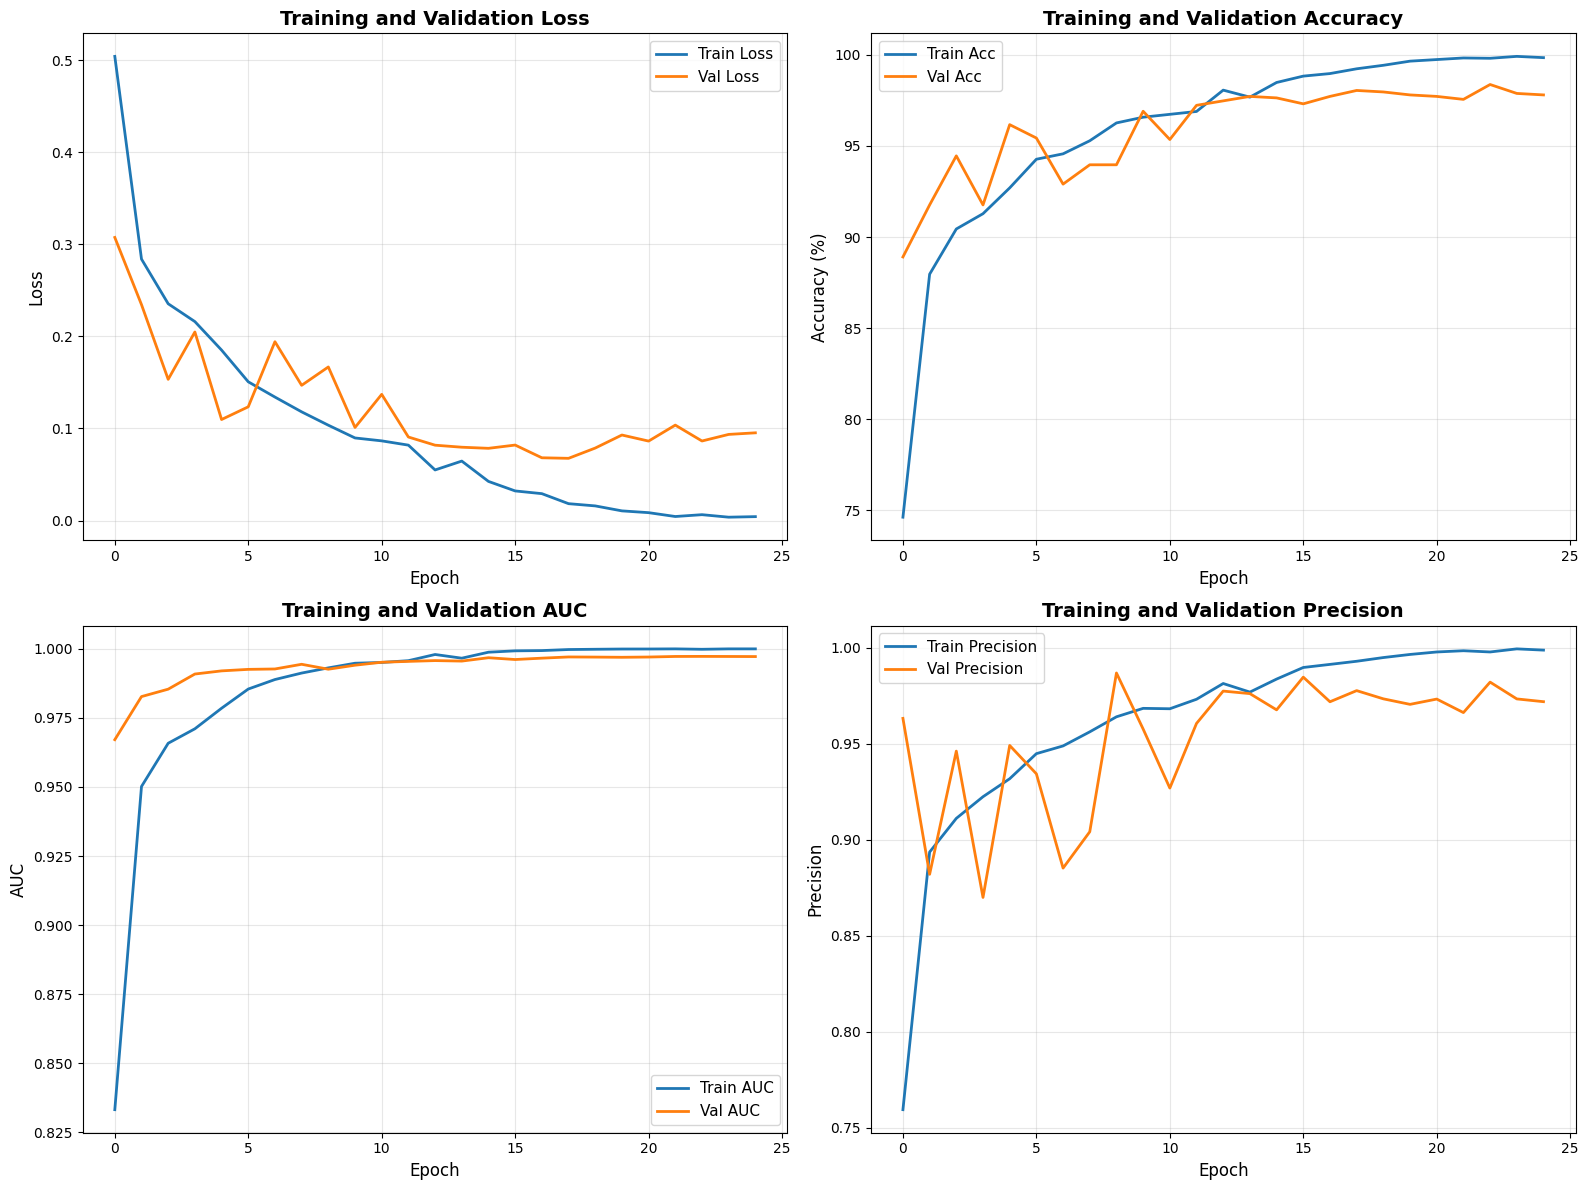

In [8]:
# %% Plot Training History
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Loss plot
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(history['train_acc'], label='Train Acc', linewidth=2)
ax2.plot(history['val_acc'], label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy (%)', fontsize=12)
ax2.set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# AUC plot
ax3.plot(history['train_auc'], label='Train AUC', linewidth=2)
ax3.plot(history['val_auc'], label='Val AUC', linewidth=2)
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('AUC', fontsize=12)
ax3.set_title('Training and Validation AUC', fontsize=14, fontweight='bold')
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# Precision plot
ax4.plot(history['train_precision'], label='Train Precision', linewidth=2)
ax4.plot(history['val_precision'], label='Val Precision', linewidth=2)
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Precision', fontsize=12)
ax4.set_title('Training and Validation Precision', fontsize=14, fontweight='bold')
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()

In [39]:
# %% Load Best Model and Evaluate on Test Set
print("\nLoading best model for testing...")
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc, test_preds, test_labels, test_probs = validate(model, test_loader, criterion, device)

print(f"\nTest Results:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

# Classification Report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=['No Nodule', 'Nodule']))

# ROC AUC Score
auc = roc_auc_score(test_labels, test_probs)
print(f"\nROC AUC Score: {auc:.4f}")


Loading best model for testing...


Validation: 100%|██████████| 77/77 [00:20<00:00,  3.79it/s]


Test Results:
Test Loss: 0.0495
Test Accuracy: 98.78%

Classification Report:
              precision    recall  f1-score   support

   No Nodule       0.99      0.98      0.99       562
      Nodule       0.99      0.99      0.99       665

    accuracy                           0.99      1227
   macro avg       0.99      0.99      0.99      1227
weighted avg       0.99      0.99      0.99      1227


ROC AUC Score: 0.9991


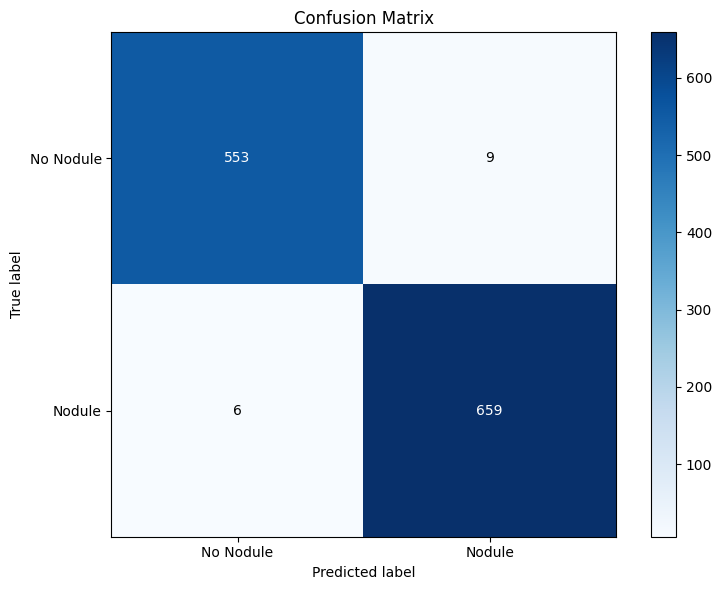


✓ Training complete! Best model saved to: best_vit_nodule_model.pth


In [ ]:
# %% Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.figure.colorbar(im, ax=ax)
ax.set(xticks=np.arange(cm.shape[1]),
       yticks=np.arange(cm.shape[0]),
       xticklabels=['No Nodule', 'Nodule'],
       yticklabels=['No Nodule', 'Nodule'],
       title='Confusion Matrix',
       ylabel='True label',
       xlabel='Predicted label')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

print("\n✓ Training complete! Best model saved to:", best_model_path)

In [ ]:
# %% GradCAM Analysis with Localization Metrics
# Install if needed: pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.reshape_transforms import vit_reshape_transform
import cv2

print("\n" + "="*70)
print("GRAD-CAM LOCALIZATION ANALYSIS")
print("="*70)


# %% Load Best Model
print("\nLoading best model from ./best_vit_nodule_model.pth...")
best_model_checkpoint = torch.load('./best_vit_nodule_model.pth', map_location=device)
model = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=2)
model.load_state_dict(best_model_checkpoint['model_state_dict'])
model = model.to(device)
model.eval()
print(f"✓ Model loaded (Val Acc: {best_model_checkpoint['val_acc']:.2f}%)")

# %% Setup for original data
original_base_path = "./dataset_nodule21/cxr_images/proccessed_data"
original_images_path = os.path.join(original_base_path, "images")
original_csv_path = os.path.join(original_base_path, "metadata.csv")

# Load original metadata
print(f"\nLoading original metadata from {original_csv_path}...")
original_metadata = pd.read_csv(original_csv_path)
print(f"Total samples in original data: {len(original_metadata)}")

# Filter for positive samples only (with nodules)
positive_samples = original_metadata[original_metadata['label'] == 1].reset_index(drop=True)
print(f"Positive samples (with nodules): {len(positive_samples)}")


GRAD-CAM LOCALIZATION ANALYSIS

Loading best model from ./best_vit_nodule_model.pth...
✓ Model loaded (Val Acc: 98.37%)

Loading original metadata from ./dataset_nodule21/cxr_images/proccessed_data\metadata.csv...
Total samples in original data: 5224
Positive samples (with nodules): 1476


In [15]:
# %% Localization Metric Functions
def calculate_iou(heatmap, bbox, threshold=0.5):
    """
    Calculate IoU between thresholded heatmap and ground truth bbox
    bbox: [x, y, width, height]
    """
    h, w = heatmap.shape
    binary_heatmap = (heatmap > threshold).astype(np.uint8)
    
    # Create ground truth mask
    gt_mask = np.zeros((h, w), dtype=np.uint8)
    
    # Scale bbox to heatmap size
    scale_x = w / IMAGE_SIZE
    scale_y = h / IMAGE_SIZE
    
    x_start = int(bbox[0] * scale_x)
    y_start = int(bbox[1] * scale_y)
    x_end = int((bbox[0] + bbox[2]) * scale_x)
    y_end = int((bbox[1] + bbox[3]) * scale_y)
    
    # Clip to valid range
    x_start = np.clip(x_start, 0, w-1)
    y_start = np.clip(y_start, 0, h-1)
    x_end = np.clip(x_end, 0, w)
    y_end = np.clip(y_end, 0, h)
    
    if x_end > x_start and y_end > y_start:
        gt_mask[y_start:y_end, x_start:x_end] = 1
    
    # Calculate IoU
    intersection = np.logical_and(binary_heatmap, gt_mask).sum()
    union = np.logical_or(binary_heatmap, gt_mask).sum()
    
    iou = intersection / union if union > 0 else 0.0
    return iou

def pointing_game(heatmap, bbox):
    """
    Check if max activation falls within bbox
    Returns: 1 if hit, 0 if miss
    """
    max_y, max_x = np.unravel_index(heatmap.argmax(), heatmap.shape)
    
    # Scale to image coordinates
    h, w = heatmap.shape
    point_x = (max_x / w) * IMAGE_SIZE
    point_y = (max_y / h) * IMAGE_SIZE
    
    # Check if within bbox
    x_min, y_min = bbox[0], bbox[1]
    x_max = bbox[0] + bbox[2]
    y_max = bbox[1] + bbox[3]
    
    hit = (x_min <= point_x <= x_max) and (y_min <= point_y <= y_max)
    return 1 if hit else 0

In [19]:
# %% Evaluate GradCAM on Positive Samples
print("\nEvaluating GradCAM localization on positive samples...")

# For ViT, we need to use a different approach
# Target the last attention block
target_layers = [model.blocks[-1].norm1]

# Custom reshape function for ViT small (patch size 16, image size 224)
def custom_reshape_transform(tensor, height=14, width=14):
    """
    Reshape ViT output to spatial format
    ViT small with patch 16 on 224x224 image has 14x14 = 196 patches
    """
    result = tensor[:, 1:, :].reshape(tensor.size(0), height, width, tensor.size(2))
    result = result.transpose(2, 3).transpose(1, 2)
    return result

cam = GradCAM(model=model, 
              target_layers=target_layers,
              reshape_transform=custom_reshape_transform)

iou_scores = []
pointing_hits = []
visualization_samples = []

for idx in tqdm(range(len(positive_samples)), desc="Analyzing"):
    row = positive_samples.iloc[idx]
    img_path = os.path.join(original_images_path, row['img_name'])
    
    if not os.path.exists(img_path):
        continue
    
    try:
        # Load image
        sitk_img = sitk.ReadImage(img_path)
        img_array = sitk.GetArrayFromImage(sitk_img)
        
        if len(img_array.shape) == 3:
            img_array = img_array[0]
        
        # Normalize to 0-255
        img_array = img_array.astype(np.float32)
        img_min, img_max = img_array.min(), img_array.max()
        if img_max > img_min:
            img_array = ((img_array - img_min) / (img_max - img_min) * 255).astype(np.uint8)
        else:
            continue
        
        # Convert to 3-channel
        img_3ch = np.stack([img_array, img_array, img_array], axis=-1)
        
        from PIL import Image
        pil_img = Image.fromarray(img_3ch)
        input_tensor = val_transform(pil_img).unsqueeze(0).to(device)
        
        # Generate GradCAM
        targets = [ClassifierOutputTarget(1)]  # Target nodule class
        grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
        grayscale_cam = grayscale_cam[0, :]  # Get first image in batch
        
        # The heatmap is already 14x14, resize to IMAGE_SIZE (224x224)
        heatmap_resized = cv2.resize(grayscale_cam, (IMAGE_SIZE, IMAGE_SIZE), 
                                    interpolation=cv2.INTER_CUBIC)
        
        # Get bbox
        bbox = [row['x'], row['y'], row['width'], row['height']]
        
        # Calculate metrics
        iou = calculate_iou(heatmap_resized, bbox, threshold=0.5)
        hit = pointing_game(heatmap_resized, bbox)
        
        iou_scores.append(iou)
        pointing_hits.append(hit)
        
        # Save first 6 for visualization
        if len(visualization_samples) < 6:
            visualization_samples.append({
                'image': img_array,
                'heatmap': heatmap_resized,
                'bbox': bbox,
                'iou': iou,
                'hit': hit,
                'name': row['img_name']
            })
    
    except Exception as e:
        print(f"Error processing {row['img_name']}: {e}")
        continue


Evaluating GradCAM localization on positive samples...


Analyzing: 100%|██████████| 1476/1476 [01:05<00:00, 22.50it/s]


In [17]:
# %% Print Results
mean_iou = np.mean(iou_scores) if iou_scores else 0
pointing_acc = np.mean(pointing_hits) * 100 if pointing_hits else 0

print("\n" + "="*70)
print("📊 LOCALIZATION PERFORMANCE METRICS")
print("="*70)
print(f"Samples Evaluated: {len(iou_scores)}")
print(f"Mean IoU: {mean_iou:.4f}")
print(f"Pointing Game Accuracy: {pointing_acc:.2f}%")
print("="*70)


📊 LOCALIZATION PERFORMANCE METRICS
Samples Evaluated: 1476
Mean IoU: 0.0009
Pointing Game Accuracy: 0.00%


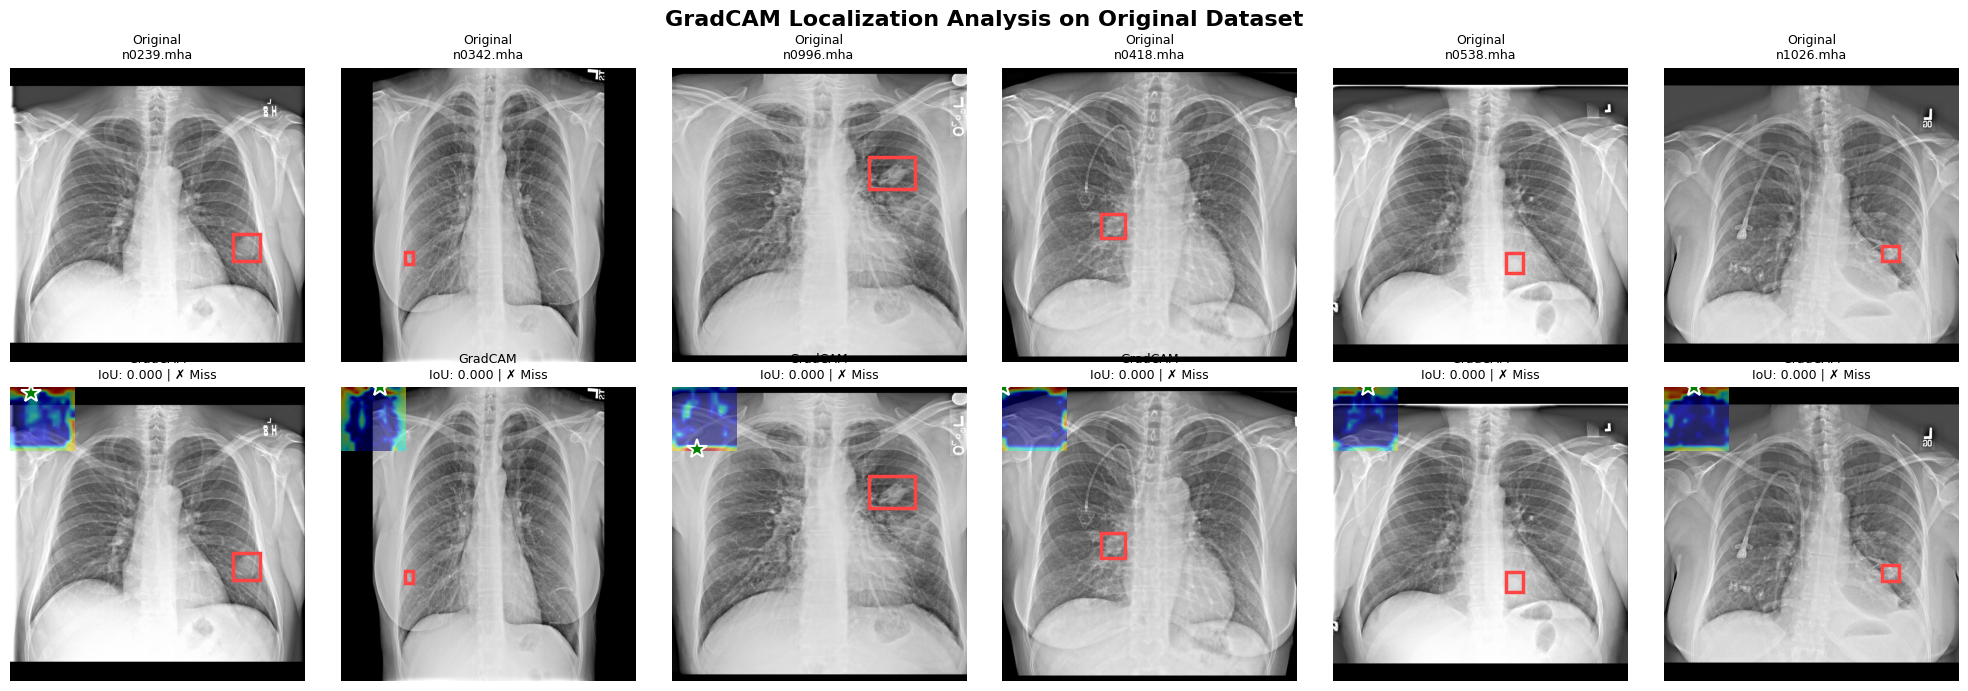


✓ Visualization saved to 'gradcam_localization.png'


In [20]:
# %% Visualize GradCAM Results
if visualization_samples:
    fig, axes = plt.subplots(2, 6, figsize=(20, 7))
    fig.suptitle('GradCAM Localization Analysis on Original Dataset', 
                 fontsize=16, fontweight='bold')
    
    for i, sample in enumerate(visualization_samples):
        # Original with bbox
        axes[0, i].imshow(sample['image'], cmap='gray')
        rect = plt.Rectangle((sample['bbox'][0], sample['bbox'][1]), 
                             sample['bbox'][2], sample['bbox'][3],
                             fill=False, edgecolor='#ff4444', linewidth=2.5)
        axes[0, i].add_patch(rect)
        axes[0, i].set_title(f"Original\n{sample['name']}", fontsize=9)
        axes[0, i].axis('off')
        
        # Heatmap overlay
        axes[1, i].imshow(sample['image'], cmap='gray')
        axes[1, i].imshow(sample['heatmap'], cmap='jet', alpha=0.5)
        rect = plt.Rectangle((sample['bbox'][0], sample['bbox'][1]), 
                             sample['bbox'][2], sample['bbox'][3],
                             fill=False, edgecolor='#ff4444', linewidth=2.5)
        axes[1, i].add_patch(rect)
        
        # Mark max activation point
        max_y, max_x = np.unravel_index(sample['heatmap'].argmax(), sample['heatmap'].shape)
        axes[1, i].plot(max_x, max_y, 'g*', markersize=15, 
                       markeredgecolor='white', markeredgewidth=1.5)
        
        status = "✓ Hit" if sample['hit'] else "✗ Miss"
        axes[1, i].set_title(f"GradCAM\nIoU: {sample['iou']:.3f} | {status}", fontsize=9)
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.savefig('gradcam_localization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualization saved to 'gradcam_localization.png'")